keys: ['n_evals', 'X_history', 'metric_history', 'true_pareto_X', 'true_pareto_Y', 'true_hv', 'n_points_in_tr', 'n_points_in_tr_collected_by_other', 'n_points_in_tr_collected_by_sobol', 'tr_sizes', 'tr_centers', 'tr_restarts', 'fit_times', 'gen_times', 'tr_indices']
len(true_hv): 1 first: [34.92066167907249] last: [34.92066167907249]


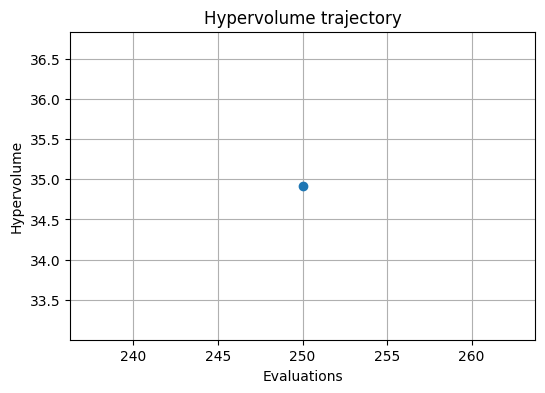

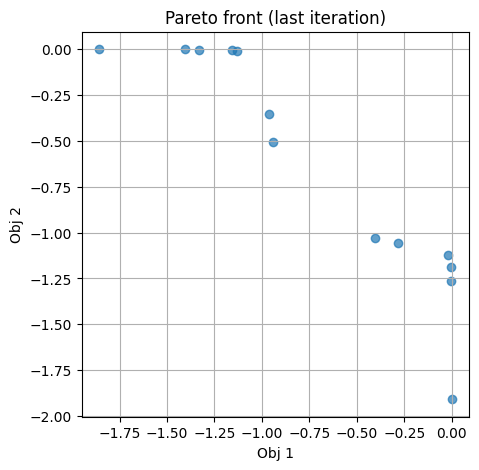

In [ ]:
import torch
import matplotlib.pyplot as plt

import os
# Change to working directory
os.chdir("c:/Users/fifof/CAPE/morbo_cape_ff")

# Path to the saved experiment data
path = "experiments/dtlz2_10d/morbo/0000_morbo.pt"
data = torch.load(path, map_location="cpu")

true_hv = data.get("true_hv", [])
n_evals = data.get("n_evals", [])
pareto_Y = data.get("true_pareto_Y", [])

print(f"keys: {list(data.keys())}")
print(f"len(true_hv): {len(true_hv)} first: {true_hv[:3]} last: {true_hv[-3:]}")

# Hypervolume vs evals
plt.figure(figsize=(6,4))
plt.plot(n_evals, true_hv, marker="o")
plt.xlabel("Evaluations")
plt.ylabel("Hypervolume")
plt.title("Hypervolume trajectory")
plt.grid(True)
plt.show()

# Scatter last Pareto front (for 2 objectives)
if pareto_Y and len(pareto_Y[-1]) and len(pareto_Y[-1][0]) >= 2:
    Y = torch.tensor(pareto_Y[-1])
    plt.figure(figsize=(5,5))
    plt.scatter(Y[:,0], Y[:,1], alpha=0.7)
    plt.xlabel("Obj 1")
    plt.ylabel("Obj 2")
    plt.title("Pareto front (last iteration)")
    plt.grid(True)
    plt.show()
